# Confidence intervals on a more skewed variable: sale price

*Part 2 · Lesson 12 · another dataset  ·  data: Ames housing sale price*

*↩ A companion to [Lesson 12: What a 95% confidence interval really means](12-confidence-intervals.ipynb).*

**↩ Back:** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](12-confidence-intervals~the-code.ipynb)

The flagship demo built **100 confidence intervals** from real data and watched about 95 of them catch
the true mean — using **living area** (square feet), a *right-skewed* variable. Here we re-run the exact
same experiment on a variable that is **even more lopsided**: the **sale price** of those same Ames homes.

A confidence interval (CI) is a range we report around an estimate — a band that says "the true mean is
plausibly in here." The promise of a **95% CI** is that the *recipe* catches the true mean about 95% of
the time. The honest question this lesson asks:

> Living area was already skewed, and 95% confidence held up. **Sale price is *more* skewed still** — a
> longer, heavier tail of expensive homes. Does the 95% promise survive an even more lopsided population?

Short answer: **yes — by a sample of n = 50 the coverage has climbed back to about 94%**, a hair under the
promised 95% but essentially holding, thanks to the Central Limit Theorem. There is an honest wrinkle worth
seeing, though: at a *very small* sample the extra skew bites and coverage dips clearly below 95%, fully
recovering only once the sample is larger still. We'll watch all of it happen.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

population = ames['price'].dropna().to_numpy()   # treat the WHOLE file as the population
MU = population.mean()                           # the TRUE mean (we get to know it!)
SIGMA = population.std(ddof=0)                    # the TRUE population standard deviation
N_POP = len(population)
print(f'Population: {N_POP:,} homes (sale price, dollars)')
print(f'TRUE population mean  MU    = {MU:,.0f} dollars   <- the answer we will try to catch')
print(f'TRUE population stdev SIGMA = {SIGMA:,.0f} dollars')
print(f'Median sale price           = {np.median(population):,.0f} dollars')

Population: 2,930 homes (sale price, dollars)
TRUE population mean  MU    = 180,796 dollars   <- the answer we will try to catch
TRUE population stdev SIGMA = 79,873 dollars
Median sale price           = 160,000 dollars


## First, meet the population — and how lopsided it is

Below is every home's sale price. The dashed line is the **true mean** μ (the number we will spend the
rest of the lesson trying to catch with samples). Notice how the bulk of homes sit on the left while a
thin tail of expensive houses stretches far to the right — that long right tail is what "skew" means.

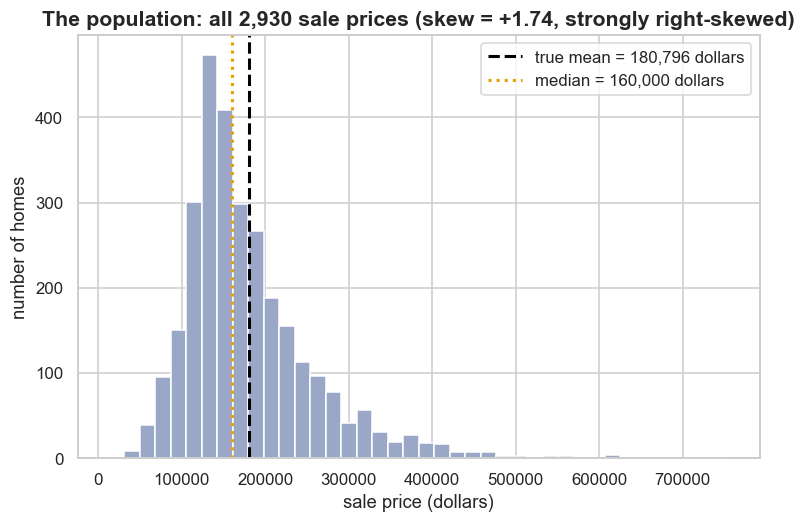

Mean (180,796) sits ABOVE median (160,000) -- the tug of the long right tail.


In [2]:
skew_price = stats.skew(population)
fig, ax = plt.subplots()
ax.hist(population, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'true mean = {MU:,.0f} dollars')
ax.axvline(np.median(population), color='#E69F00', lw=2, ls=':',
           label=f'median = {np.median(population):,.0f} dollars')
ax.set_xlabel('sale price (dollars)'); ax.set_ylabel('number of homes')
ax.set_title(f'The population: all {N_POP:,} sale prices (skew = {skew_price:+.2f}, strongly right-skewed)')
ax.legend(); plt.show()
print(f'Mean ({MU:,.0f}) sits ABOVE median ({np.median(population):,.0f}) -- the tug of the long right tail.')

### How this compares to the flagship's living area

The flagship used **living area**, already a right-skewed variable. Sale price is **more** skewed still.
A quick side-by-side of the two skew numbers makes the contrast concrete — *higher means more lopsided*.

Skew of living area (the flagship variable) = +1.27
Skew of sale price  (this lesson)           = +1.74   <- more lopsided


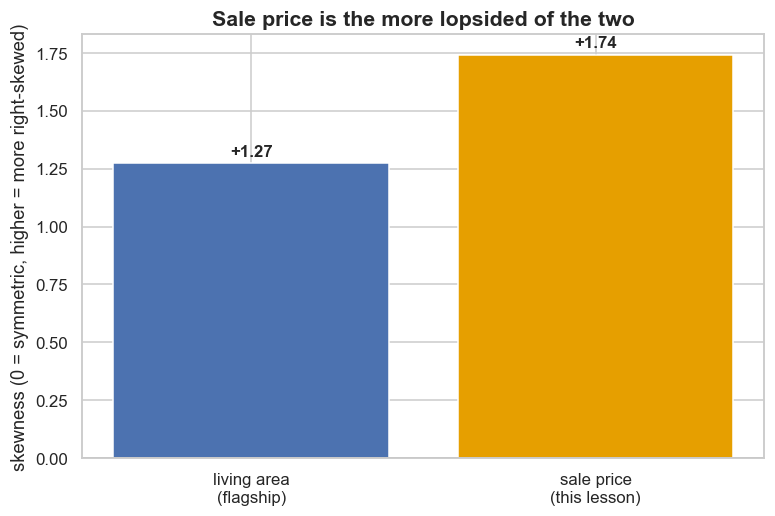

In [3]:
area = ames['area'].dropna().to_numpy()
skew_area = stats.skew(area)
print(f'Skew of living area (the flagship variable) = {skew_area:+.2f}')
print(f'Skew of sale price  (this lesson)           = {skew_price:+.2f}   <- more lopsided')

fig, ax = plt.subplots()
ax.bar(['living area\n(flagship)', 'sale price\n(this lesson)'], [skew_area, skew_price],
       color=['#4c72b0', '#E69F00'])
ax.axhline(0, color='grey', lw=1)
ax.set_ylabel('skewness (0 = symmetric, higher = more right-skewed)')
ax.set_title('Sale price is the more lopsided of the two')
for i, v in enumerate([skew_area, skew_price]):
    ax.text(i, v + 0.03, f'{v:+.2f}', ha='center', fontweight='bold')
plt.show()

## Step 1 — one sample, one interval

In real life you can't measure every home — you take a **sample**. From it you estimate the mean, and you
report a **confidence interval**: a range that says "the true mean price is plausibly in here."

For a mean, the 95% CI is:

$$\bar{x} \;\pm\; t^{*}\cdot \frac{s}{\sqrt{n}}$$

- $\bar{x}$ — the **sample** mean (our estimate of μ).
- $s$ — the sample standard deviation (how spread the sample is).
- $n$ — the sample size. Bigger $n$ → narrower interval (that $\sqrt{n}$).
- $s/\sqrt{n}$ — the **standard error**: how much $\bar{x}$ wobbles from sample to sample.
- $t^{*}$ — a multiplier (about 2 for 95%) from the *t-distribution*, sized so the recipe works 95% of the time.

We draw the sample **without replacement** (`replace=False`): a real survey doesn't poll the same house
twice. Because our sample (n = 50) is a tiny slice of the population (N = 2,930), this changes the math by
a negligible amount — the standard "small sample from a big population" exception.

In [4]:
rng = np.random.default_rng(7)   # change this seed to draw a different sample
n = 50

def confidence_interval(sample, level=0.95):
    n = len(sample)
    xbar = sample.mean()
    s = sample.std(ddof=1)
    se = s / np.sqrt(n)
    tcrit = stats.t.ppf(1 - (1 - level) / 2, df=n - 1)
    return xbar - tcrit * se, xbar + tcrit * se, xbar

sample = rng.choice(population, size=n, replace=False)
lo, hi, xbar = confidence_interval(sample)
print(f'Sample mean  = {xbar:,.0f} dollars')
print(f'95% CI       = ({lo:,.0f}, {hi:,.0f}) dollars')
print(f'True mean MU = {MU:,.0f} dollars')
print('Did THIS interval catch the true mean? ->', 'YES' if lo <= MU <= hi else 'NO')

Sample mean  = 185,200 dollars
95% CI       = (159,440, 210,961) dollars
True mean MU = 180,796 dollars
Did THIS interval catch the true mean? -> YES


## Step 2 — do it 100 times and count

One interval either catches μ or it doesn't — that's luck. The real claim of "95% confidence" is about the
**long run**:

> If we repeated the whole process many times, about **95%** of the intervals would contain the true mean.

So let's build **100** intervals and count.

In [5]:
n_intervals = 100
results = []
for _ in range(n_intervals):
    s = rng.choice(population, size=n, replace=False)
    lo, hi, xbar = confidence_interval(s)
    results.append({'lo': lo, 'hi': hi, 'xbar': xbar, 'hit': lo <= MU <= hi})

hits = sum(r['hit'] for r in results)
print(f'{hits} out of {n_intervals} intervals contained the true mean ({MU:,.0f} dollars).')
print(f'That is {hits}% coverage - the theory predicts about 95%.')

95 out of 100 intervals contained the true mean (180,796 dollars).
That is 95% coverage - the theory predicts about 95%.


### Picture it — the "caterpillar" plot

Each horizontal line is one sample's 95% CI. Intervals that **caught** the true mean are **teal and solid (●)**;
the ones that **missed** are **orange-red and dashed (✕)** — shape *and* colour, so they read in grayscale and
for colourblind viewers. The dashed vertical line is the true mean μ. The dashed orange-red ones are the ~5% that
miss — not mistakes, just the expected price of sampling.

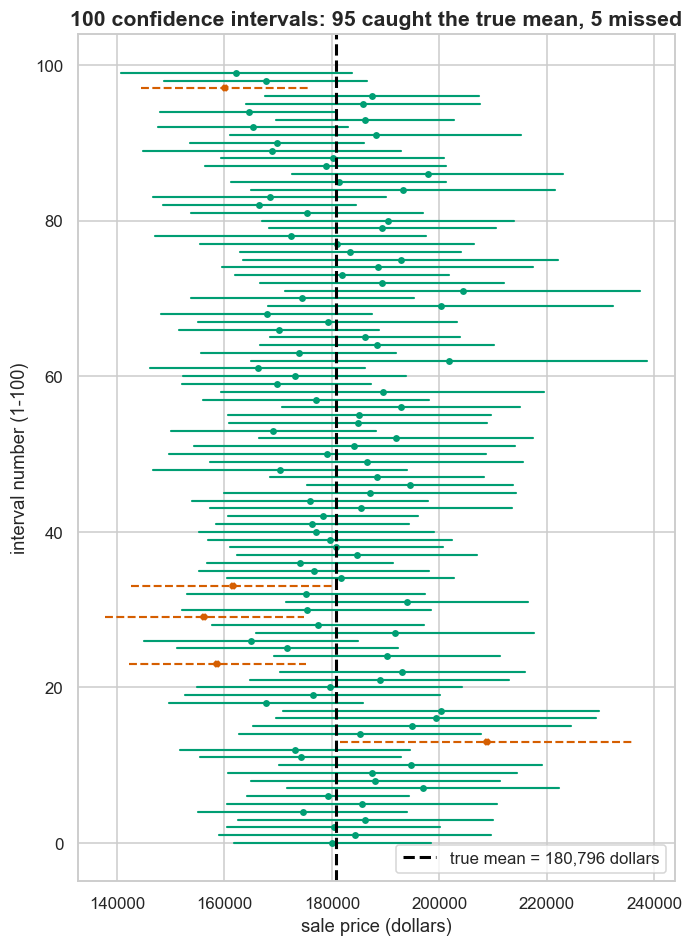

In [6]:
fig, ax = plt.subplots(figsize=(7, 10))
for i, res in enumerate(results):
    hit = res['hit']
    style = sl.hit_miss_style(hit)          # solid circle = a hit, dashed cross = a miss
    color = sl.CAPTURE if hit else sl.MISS  # colourblind-safe teal vs. vermillion
    ax.plot([res['lo'], res['hi']], [i, i], color=color, lw=1.4, ls=style['linestyle'])
    ax.plot(res['xbar'], i, color=color, ms=3.5, marker=style['marker'], ls='none')
ax.axvline(MU, color='black', ls='--', lw=2, label=f'true mean = {MU:,.0f} dollars')
ax.set_xlabel('sale price (dollars)'); ax.set_ylabel('interval number (1-100)')
ax.set_title(f'100 confidence intervals: {hits} caught the true mean, {n_intervals - hits} missed')
ax.legend(loc='lower right'); plt.show()

### What "95% confidence" does — and does *not* — mean

- ✅ **Correct:** *the procedure* catches the true mean about 95% of the time. The confidence is in the
  **method**, across many repeats.
- ❌ **Wrong:** "there's a 95% probability μ is inside *this particular* interval." Once an interval is
  computed, μ is either in it or not — the 95% is the long-run hit rate, not a probability about one interval.

That this still holds on a *more* skewed variable is the whole point of this lesson — and the next step
pins the rate down.

## Step 3 — push it to 10,000 to watch the rate settle

100 intervals landed near 95. With **10,000**, the coverage should sit very close to the promised 95% —
*even though the population is more lopsided than the flagship's*.

In [7]:
def coverage(level, n=50, trials=10000):
    hits = 0
    for _ in range(trials):
        s = rng.choice(population, size=n, replace=False)
        lo, hi, _ = confidence_interval(s, level=level)
        hits += (lo <= MU <= hi)
    return hits / trials

print(f'Coverage of the 95% method over 10,000 samples (n=50): {coverage(0.95) * 100:.1f}%')
print('Close to 95% (a hair under) -- the promise essentially holds even on the more skewed price.')

Coverage of the 95% method over 10,000 samples (n=50): 94.3%
Close to 95% (a hair under) -- the promise essentially holds even on the more skewed price.


## The honest wrinkle — skew bites when the sample is tiny

Here is the nuance the flagship didn't dwell on. The t-interval's 95% promise leans on the sample **mean**
being roughly bell-shaped, which the Central Limit Theorem (CLT) delivers — *but only once the sample is
big enough to tame the skew*. The more lopsided the population, the bigger the $n$ it takes.

So at a **very small** sample (say n = 10), the heavy right tail of sale price still leaks through, and the
95% method actually covers a bit **less** than 95% of the time. By n = 50 most of that dip is gone —
coverage is back to about 94%, just shy of the full 95% — and it closes the last sliver only as $n$ grows
further (around n = 100–200). Let's measure the coverage across several sample sizes and watch it climb.

In [8]:
sizes = [10, 30, 50, 100]
rows = []
for nn in sizes:
    rows.append({'n': nn, 'coverage_%': coverage(0.95, n=nn, trials=10000) * 100})
cov_table = pd.DataFrame(rows)
print(cov_table.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

cov10 = cov_table.loc[cov_table['n'] == 10, 'coverage_%'].iloc[0]
cov50 = cov_table.loc[cov_table['n'] == 50, 'coverage_%'].iloc[0]
print(f'\nAt n=10 the skew bites: coverage = {cov10:.1f}% (a touch BELOW the promised 95%).')
print(f'By n=50 most of the dip is gone: coverage = {cov50:.1f}% (close to 95%, a hair under).')

  n  coverage_%
 10        92.0
 30        93.3
 50        94.3
100        94.5

At n=10 the skew bites: coverage = 92.0% (a touch BELOW the promised 95%).
By n=50 most of the dip is gone: coverage = 94.3% (close to 95%, a hair under).


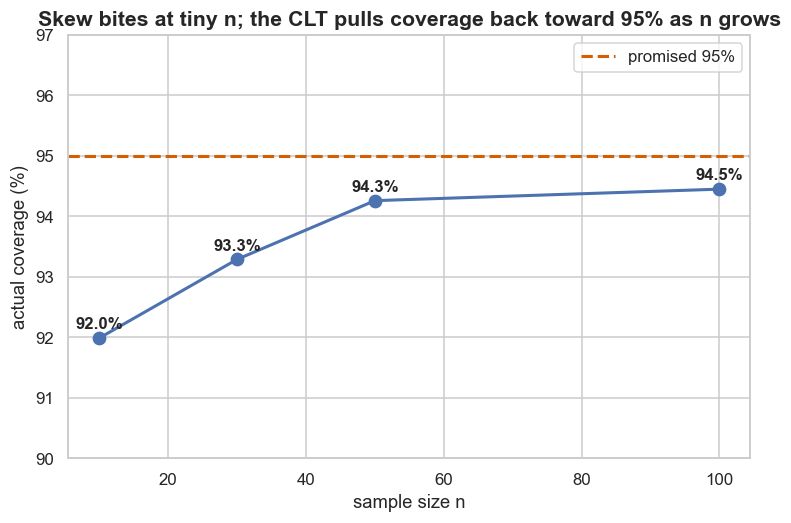

In [9]:
fig, ax = plt.subplots()
ax.plot(cov_table['n'], cov_table['coverage_%'], 'o-', color='#4c72b0', lw=2, ms=8)
ax.axhline(95, color='#D55E00', ls='--', lw=2, label='promised 95%')
for _, r in cov_table.iterrows():
    ax.text(r['n'], r['coverage_%'] + 0.15, f"{r['coverage_%']:.1f}%", ha='center', fontweight='bold')
ax.set_xlabel('sample size n'); ax.set_ylabel('actual coverage (%)')
ax.set_title('Skew bites at tiny n; the CLT pulls coverage back toward 95% as n grows')
ax.set_ylim(min(90, cov_table['coverage_%'].min() - 1), 97)
ax.legend(); plt.show()

### Higher confidence = a wider net (the trade-off)

Want to be *more* sure of catching μ? Use a higher confidence level — but the interval gets **wider** (less
precise). Let's compare 80% / 90% / 95% / 99% on both **coverage** (does it keep its promise?) and **average
width**, all at n = 50.

level  coverage_%  avg_width_dollars
  80%          80             28,865
  90%          89             37,110
  95%          95             44,689
  99%          98             59,663


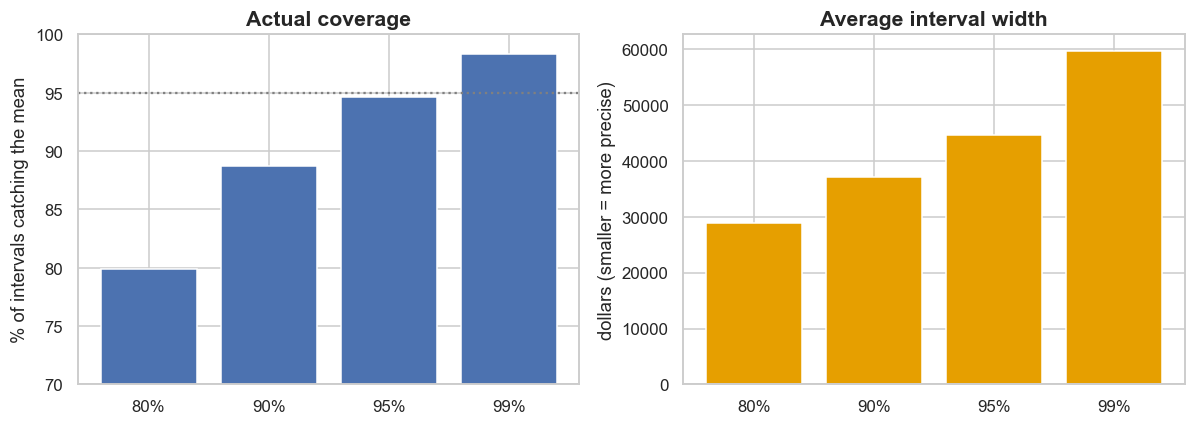

In [10]:
levels = [0.80, 0.90, 0.95, 0.99]
rows = []
for lev in levels:
    widths, hits, trials = [], 0, 5000
    for _ in range(trials):
        s = rng.choice(population, size=50, replace=False)
        lo, hi, _ = confidence_interval(s, level=lev)
        widths.append(hi - lo); hits += (lo <= MU <= hi)
    rows.append({'level': f'{int(lev*100)}%', 'coverage_%': hits / trials * 100,
                 'avg_width_dollars': np.mean(widths)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(summary['level'], summary['coverage_%'], color='#4c72b0'); a1.axhline(95, color='grey', ls=':')
a1.set_title('Actual coverage'); a1.set_ylabel('% of intervals catching the mean'); a1.set_ylim(70, 100)
a2.bar(summary['level'], summary['avg_width_dollars'], color='#E69F00')
a2.set_title('Average interval width'); a2.set_ylabel('dollars (smaller = more precise)')
plt.tight_layout(); plt.show()

## Why it works — the engine underneath (the Central Limit Theorem)

Confidence intervals lean on a near-magical fact: even though the population of sale prices is **strongly
skewed**, the **sample means** pile up into a tidy **bell curve** centered on μ. That's the **Central Limit
Theorem (CLT)**, and its spread is the standard error $\sigma/\sqrt{n}$. The CLT is exactly *why* a bigger
$n$ tamed the skew in the table above — and why a more lopsided population simply needs a slightly larger
sample to get there.

*(Lesson 10's companion builds this same engine on Ames sale price from scratch — it shows that price needs
a slightly larger sample than living area before the bell curve emerges, the very fact that explains the
small-n dip we just saw.)*

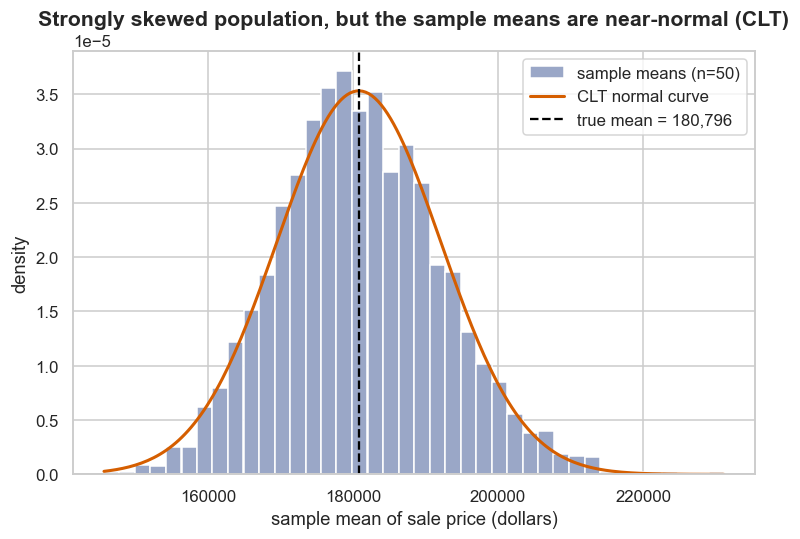

Std of the sample means      = 11,305 dollars
CLT prediction sigma/sqrt(n) = 11,296 dollars   (they should match)


In [11]:
many_means = np.array([rng.choice(population, size=50, replace=False).mean() for _ in range(5000)])
fig, ax = plt.subplots()
ax.hist(many_means, bins=40, density=True, color='#9aa7c7', edgecolor='white', label='sample means (n=50)')
xs = np.linspace(many_means.min(), many_means.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(50)), color='#D55E00', lw=2, label='CLT normal curve')
ax.axvline(MU, color='black', ls='--', label=f'true mean = {MU:,.0f}')
ax.set_xlabel('sample mean of sale price (dollars)'); ax.set_ylabel('density')
ax.set_title('Strongly skewed population, but the sample means are near-normal (CLT)')
ax.legend(); plt.show()
print(f'Std of the sample means      = {many_means.std():,.0f} dollars')
print(f'CLT prediction sigma/sqrt(n) = {SIGMA / np.sqrt(50):,.0f} dollars   (they should match)')

## Now you try

Predict first, then change a number and re-run:

1. **Sample size `n`** — set `n = 10`, then `n = 200`, in the Step-1 cell. Wider or narrower intervals? Use
   the coverage table to predict whether the 95% promise holds at each.
2. **The seed** — change `np.random.default_rng(7)` to any number for a fresh batch. Roughly how many of
   100 still hit?
3. **Back to living area** — swap `ames['price']` for `ames['area']` (the flagship variable). The skew is
   milder; does the small-n dip shrink? (It should — less skew, less bite.)

## What you learned

- The **same 100-interval coverage demo** works on **sale price**, a *more* skewed variable (skew ≈ +1.74)
  than the flagship's living area (≈ +1.27).
- At **n = 50** the 95% method covers about **94%** of the time — just shy of the promise, but the extra
  skew is largely absorbed by the **Central Limit Theorem** making the sample mean near-normal.
- **The honest wrinkle:** at a *tiny* sample (n = 10) the heavy right tail leaks through and coverage dips
  clearly **below** 95%; it climbs back toward 95% as $n$ grows (about 94% by n = 50, the full 95% only by
  roughly n = 100–200). *More skew simply needs a larger sample.*
- **The math:** $\bar{x} \pm t^{*}\, s/\sqrt{n}$ — an estimate plus-or-minus a multiplier times the standard
  error. **The meaning:** a range of plausible values for the unknown true mean. **The interpretation:**
  "95% confidence" is the **method's long-run hit rate**, not a probability about one fixed interval.

---

**↩ Back to the lesson:** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](12-confidence-intervals~the-code.ipynb)